# 04 · Feature engineering & split — turning tender details into model clues

## Step 1 · Load the clean table

In [116]:
# pandas = tables, numpy = maths helpers (we need log later)
import pandas as pd
import numpy as np

In [117]:
# Let Python look one folder up, where tenderlens_style.py lives
import sys
sys.path.append("..")

# Bring in my colours and chart helpers with the short name ts
import tenderlens_style as ts

In [118]:
# The three columns that hold dates
dates = ["published_date", "last_date", "bid_opening_date"]

# Open the clean table from S2 and read those columns as real dates
df = pd.read_csv("../data/interim/tenders_clean.csv", parse_dates=dates)

In [119]:
# How big is the table? (rows, columns)
df.shape

(39411, 39)

In [120]:
# Is the table still in date order? (True = oldest tender first)
df["published_date"].is_monotonic_increasing

True

## Step 2 · Repeat clues (same-day lots vs quick re-tenders)

In [121]:
# Days since the same department last posted the same title (empty if never before)
df["days_since_same"] = df.groupby(["dept_main", "title_key"])["published_date"].diff().dt.days

In [122]:
# 1 if posted on the SAME day as its twin (a lot), else 0
df["same_day_lot"] = (df["days_since_same"] == 0).astype(int)

In [123]:
# 1 if the twin was posted 1 to 60 days earlier (a quick re-tender), else 0
df["retender_60d"] = df["days_since_same"].between(1, 60).astype(int)

In [124]:
# Count each clue: how many tenders have a gap, how many lots, how many quick re-tenders
print("Has a gap   :", df["days_since_same"].notna().sum())
print("Same-day lot:", df["same_day_lot"].sum())
print("Re-tender 60:", df["retender_60d"].sum())

Has a gap   : 5786
Same-day lot: 1734
Re-tender 60: 2820


## Step 3 · Year-end clue (months left until 31 March)

In [125]:
# Month number of each tender (1 = Jan ... 12 = Dec)
pub_m = df["published_date"].dt.month

In [126]:
# Months left until the financial year ends on 31 March (March = 0, April = 11)
df["months_to_fy_end"] = (3 - pub_m) % 12

In [127]:
# Check: one row per month showing its months-left number
df.groupby(pub_m)["months_to_fy_end"].first()

published_date
1      2
2      1
3      0
4     11
5     10
6      9
7      8
8      7
9      6
10     5
11     4
12     3
Name: months_to_fy_end, dtype: int32

## Step 4 · Value clues (log value + missing flag)

In [128]:
# Squeeze giant rupee values with log (log1p = log of value + 1, safe for 0)
df["log_value"] = np.log1p(df["estimated_value"])

In [129]:
# Turn True/False into 1/0 (1 = the tender has no value written)
df["value_missing"] = df["value_missing"].astype(int)

In [130]:
# Before vs after: middle and biggest value
print("Rupees median:", df["estimated_value"].median(), " max:", df["estimated_value"].max())
print("Log    median:", round(df["log_value"].median(), 1), " max:", round(df["log_value"].max(), 1))

Rupees median: 9836462.0  max: 20000000000.0
Log    median: 16.1  max: 23.7


In [131]:
# Missing values: both counts should be the same
print("Empty log_value:", df["log_value"].isna().sum())
print("value_missing=1:", df["value_missing"].sum())

Empty log_value: 5382
value_missing=1: 5382


## Step 5 · Labelled tenders + time split (train / validation / test)

In [132]:
# Keep only tenders where we know the answer (copy = a separate table we can safely change)
lab = df[df["single_bid"].notna()].copy()
lab.shape

(6790, 44)

In [133]:
# Everyone starts in train (published up to Sep 2022)
lab["split"] = "train"

# Oct-Dec 2022 tenders move to validation
lab.loc[lab["published_date"] >= "2022-10-01", "split"] = "val"

# Jan-May 2023 tenders move to test
lab.loc[lab["published_date"] >= "2023-01-01", "split"] = "test"

In [134]:
# How many tenders in each set?
lab["split"].value_counts()

split
train    2839
val      2416
test     1535
Name: count, dtype: int64

In [135]:
# Single-bid rate (%) in each set
(lab.groupby("split")["single_bid"].mean() * 100).round(1)

split
test     22.5
train    36.3
val      27.7
Name: single_bid, dtype: float64

## Step 6 · Keep shared reference numbers in one set

In [136]:
# For each reference number, how many different sets is it in?
sets_per_ref = lab.groupby("reference_no")["split"].nunique()

# How many reference numbers sit in more than one set?
(sets_per_ref > 1).sum()

46

In [137]:
# One example: same reference number, two different works, two different sets
lab[lab["reference_no"] == "15th FC 09 of 2021-22"][["published_date", "title", "split"]]

,published_date,title,split
33378,2022-09-16 10:00:00,Imp of road with Earth filling,train
36135,2022-12-14 10:00:00,Market Shed,val


In [138]:
# Give each set a number in time order: train = 0, val = 1, test = 2
lab["split_num"] = lab["split"].map({"train": 0, "val": 1, "test": 2})

In [139]:
# For each reference number, find its LATEST set (biggest number) and give it to every tender in the group
lab["group_num"] = lab.groupby("reference_no")["split_num"].transform("max")

In [140]:
# How many tenders have to move forward?
(lab["split_num"] != lab["group_num"]).sum()

291

In [141]:
# Turn the numbers back into set names (this is the new, fixed split)
lab["split"] = lab["group_num"].map({0: "train", 1: "val", 2: "test"})

# Remove the two helper columns, we don't need them any more
lab = lab.drop(columns=["split_num", "group_num"])

In [142]:
# Check: every reference number is now in only ONE set (should print 1)
lab.groupby("reference_no")["split"].nunique().max()

1

In [143]:
# New counts and single-bid rate (%) for each set
print(lab["split"].value_counts())
print((lab.groupby("split")["single_bid"].mean() * 100).round(1))

split
train    2753
val      2270
test     1767
Name: count, dtype: int64
split
test     23.8
train    36.1
val      27.8
Name: single_bid, dtype: float64


### Insight · Time split (Steps 5 and 6)
- I kept only the 6,790 tenders where the bid count is known. The other 32,621 older tenders stay in df because they helped build the repeat clues, but they cannot be used to train or test the model.
- I split by date, not randomly. Train is up to Sep 2022, validation is Oct to Dec 2022 and test is Jan to May 2023. A random split would be like seeing next year's exam paper while studying, so the score would look good but be fake.
- 46 reference numbers were shared across sets. Some offices reuse one file number for many different works, for example the same number was used for a road in Sep 2022 and a market shed in Dec 2022.
- Tenders with the same reference number usually come from the same office and the same local contractors. If they sit in both train and test, the model has already seen part of the answer. This is called leakage.
- To fix it I moved each group forward into the latest set it touches. 291 tenders moved: 86 out of train and 205 from validation into test. I moved them forward, not back, so train still has only tenders up to Sep 2022.
- Final split: train 2,753 tenders (36.1% single-bid), validation 2,270 (27.8%), test 1,767 (23.8%). All 6,790 are still there.
- The single-bid rate keeps falling over time: 36.1%, then 27.8%, then 23.8%. This is called drift. The model learns from a past with more single-bid tenders than the future it will be checked on.
- Because of the drift, the model may predict too many single-bid tenders on new data. In S5 I need to tune the threshold on validation and check calibration, not just trust training numbers.
- The test set is used only once, at the very end (Gate 2). December 2022 is a big part of validation and had an unusually low rate, so in S5 I will report Oct-Nov and December separately.

## Step 7 · Department clue, part 1 (rates from training, for val and test)

In [144]:
# Only the training tenders
tr = lab[lab["split"] == "train"]

# Overall single-bid rate in training (our "average" to lean on)
overall = tr["single_bid"].mean()
overall

0.36069742099527785

In [145]:
# Smoothing strength: pretend each department has 20 extra average tenders
k = 20

In [146]:
# For each department: number of training tenders, and number of single-bid ones
dept_n = tr.groupby("dept_main")["single_bid"].count()
dept_ones = tr.groupby("dept_main")["single_bid"].sum()

# How many departments appear in training?
len(dept_n)

77

In [147]:
# Smoothed rate = (real single-bids + 20 average ones) / (real tenders + 20)
dept_rate = (dept_ones + k * overall) / (dept_n + k)

In [148]:
# Compare raw vs smoothed for a tiny department and a big one
check = pd.DataFrame({"tenders": dept_n, "single": dept_ones,
                      "raw %": (dept_ones / dept_n * 100).round(1),
                      "smoothed %": (dept_rate * 100).round(1)})
check.loc[["Assam Police", "Public Works Roads Department"]]

,tenders,single,raw %,smoothed %
dept_main,,,,
Assam Police,3,0.0,0.0,31.4
Public Works Roads Department,263,116.0,44.1,43.5


In [149]:
# Which rows are validation or test?
not_train = lab["split"] != "train"

# Give them their department's training rate (unknown departments get the overall rate)
lab.loc[not_train, "dept_rate"] = lab.loc[not_train, "dept_main"].map(dept_rate).fillna(overall)

In [150]:
# Checks: no empty rates, and how many val/test tenders used the overall rate
print("Empty dept_rate :", lab.loc[not_train, "dept_rate"].isna().sum())
print("Used overall    :", (~lab.loc[not_train, "dept_main"].isin(dept_rate.index)).sum())

Empty dept_rate : 0
Used overall    : 16


## Step 8 · Department clue, part 2 (training tenders use only earlier tenders)

In [151]:
# For each training tender: how many EARLIER training tenders its department had (0 for the first)
prior_n = tr.groupby("dept_main").cumcount()

In [152]:
# Running total of single-bids in the department, minus this tender's own answer
prior_ones = tr.groupby("dept_main")["single_bid"].cumsum() - tr["single_bid"]

In [153]:
# Smoothed rate from earlier tenders only, written into the training rows of lab
lab.loc[tr.index, "dept_rate"] = (prior_ones + k * overall) / (prior_n + k)

In [154]:
# Look at the first 5 PWD Roads training tenders to see the clue "learning"
ex = tr[["published_date", "single_bid"]].assign(before=prior_n, ones_before=prior_ones,
                                                dept_rate=lab.loc[tr.index, "dept_rate"].round(3))
ex[tr["dept_main"] == "Public Works Roads Department"].head(5)

,published_date,single_bid,before,ones_before,dept_rate
15011,2019-01-05 13:00:00,1.0,0,0.0,0.361
15019,2019-01-05 14:00:00,0.0,1,1.0,0.391
17012,2019-03-02 10:10:00,1.0,2,1.0,0.373
17342,2019-03-12 14:00:00,1.0,3,2.0,0.401
23890,2020-05-18 16:00:00,0.0,4,3.0,0.426


In [155]:
# Checks: no empty rates anywhere, and the average dept_rate in each set
print("Empty dept_rate:", lab["dept_rate"].isna().sum())
print(lab.groupby("split")["dept_rate"].mean().round(3))

Empty dept_rate: 0
split
test     0.342
train    0.364
val      0.364
Name: dept_rate, dtype: float64


### Insight · Department clue (Steps 7 and 8)
- A model cannot read department names, so I turned each department into a number: its single-bid rate in training. This is called target encoding.
- Small departments give unreliable rates. Assam Police had only 3 training tenders and none were single-bid, so its raw rate was 0%. Judging from 3 tenders is like judging a cricketer after 3 balls.
- I used smoothing: every department gets 20 pretend average tenders at the training rate of 36.1%. Big departments barely change (PWD Roads 44.1% to 43.5%), small ones are pulled towards the average (Assam Police 0% to 31.4%).
- Validation and test tenders use rates learned from training only. 16 of them come from departments never seen in training, so they get the average 36.1%.
- Training tenders use only tenders from their department published before them. If I used the full training rate, each tender's own answer would be inside its own clue, and the model would learn from leaked answers.
- So the clue starts at the average for a department's first tender and slowly learns its habit. PWD Roads starts at 36.1% and reaches 43.7% by Sep 2022.
- Every one of the 6,790 tenders now has a dept_rate, with no empty values.

## Step 9 · Final clue list + fill missing values (training medians only)

In [156]:
# The 7 clues the model will read
features = ["dept_rate", "log_value", "value_missing", "bid_window_days",
            "months_to_fy_end", "same_day_lot", "retender_60d"]

In [157]:
# How many empty cells does each clue have?
lab[features].isna().sum()

dept_rate              0
log_value           1017
value_missing          0
bid_window_days        4
months_to_fy_end       0
same_day_lot           0
retender_60d           0
dtype: int64

In [158]:
# Middle value of each gappy clue, from TRAINING tenders only
fill_values = lab.loc[lab["split"] == "train", ["log_value", "bid_window_days"]].median()
fill_values

log_value          15.958633
bid_window_days    19.000000
dtype: float64

In [159]:
# Fill the gaps with the training middle values
lab["log_value"] = lab["log_value"].fillna(fill_values["log_value"])
lab["bid_window_days"] = lab["bid_window_days"].fillna(fill_values["bid_window_days"])

In [160]:
# Check: total empty cells across all 7 clues (should be 0)
lab[features].isna().sum().sum()

0

## Step 10 · Chart: single-bid rate in train, validation and test

In [161]:
# Chart tools, plus os for making folders
import matplotlib.pyplot as plt
import os

In [162]:
# Single-bid rate (%) per set, in time order (train, val, test)
order = ["train", "val", "test"]
rate = (lab.groupby("split")["single_bid"].mean() * 100).reindex(order)
rate

split
train    36.069742
val      27.753304
test     23.825693
Name: single_bid, dtype: float64

In [163]:
# Teal shades from my style file, light to dark as time moves forward (train → val → test)
colors = [ts.BLUES[1], ts.BLUES[2], ts.BLUES[3]]

# Bar names with dates and tender counts underneath
names = ["Train\nup to Sep 2022\n2,753 tenders",
         "Validation\nOct-Dec 2022\n2,270 tenders",
         "Test\nJan-May 2023\n1,767 tenders"]

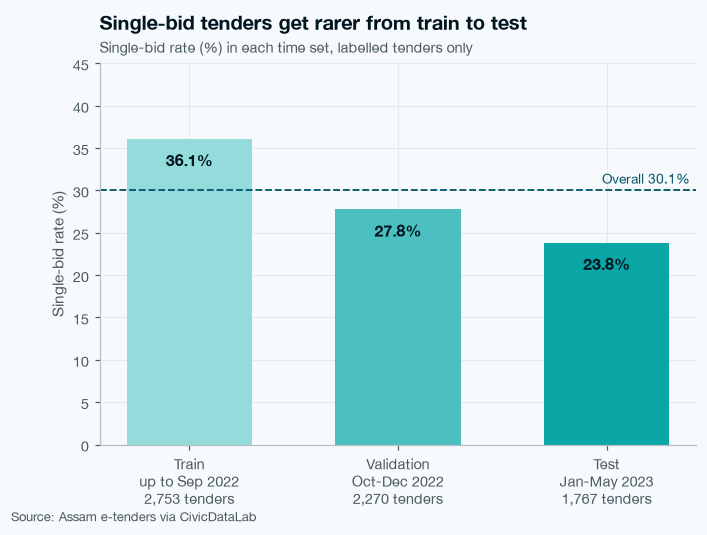

In [164]:
# Draw the bars
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(names, rate, color=colors, width=0.6)

# Dashed benchmark line at the overall 30.1% with a small label
ax.axhline(30.1, color=ts.THIRD, linestyle="--", linewidth=1.2)
ax.text(2.4, 30.8, "Overall 30.1%", color=ts.THIRD, ha="right", fontsize=9)

# % labels inside the top of each bar (so they don't hit the dashed line)
ax.bar_label(bars, fmt="%.1f%%", padding=-20, color=ts.NAVY, fontweight="bold")

# Room at the top, and a y-axis name
ax.set_ylim(0, 45)
ax.set_ylabel("Single-bid rate (%)")

# Title = the finding, subtitle = what is measured, then the source line
ts.title(ax, "Single-bid tenders get rarer from train to test",
         subtitle="Single-bid rate (%) in each time set, labelled tenders only")
ts.source(fig)

In [165]:
# Make sure the folder exists, then save the chart
os.makedirs("../reports/figures", exist_ok=True)
ts.save_fig(fig, "../reports/figures/S4a_split_single_bid_rate.png")

## Step 11 · Save the clue table and training settings

In [166]:
# Columns to save: ID and text columns, our 7 clues, the set name and the answer
keep = ["tender_id", "reference_no", "published_date", "dept_main", "title",
        "work_description", "estimated_value", "days_since_same"] + features + ["split", "single_bid"]

In [167]:
# Make the final table (rows, columns)
out = lab[keep]
out.shape

(6790, 17)

In [168]:
# Make sure the folder exists, then save the clue table
os.makedirs("../data/processed", exist_ok=True)
out.to_csv("../data/processed/features_split.csv", index=False)

In [169]:
# Department rates learned from training (department name stays as the first column)
dept_table = pd.DataFrame({"tenders": dept_n, "single": dept_ones, "dept_rate": dept_rate})
dept_table.to_csv("../data/processed/dept_rate_train.csv")

In [170]:
# The 4 numbers we learned from training, saved as a small table
settings = pd.Series({"overall_train_rate": overall, "smoothing_k": k,
                      "log_value_median": fill_values["log_value"],
                      "bid_window_median": fill_values["bid_window_days"]})
settings.to_csv("../reports/s4_feature_settings.csv", header=["value"])

In [171]:
# Check: open the saved clue table again and look at its size
pd.read_csv("../data/processed/features_split.csv").shape

(6790, 17)

## S4 Summary - Feature Engineering & Split

### Starting point
- I started from tenders_clean.csv from S2 (39,411 tenders, 39 columns), read with the three date columns as real dates.
- From S3 I knew which details might matter: quick re-tenders, department, value, missing value and the year-end rush.
- A model can only read numbers, and it must never see the answer or the future, so S4 was about making safe clues and splitting the data properly.

### What I did
- Re-made days_since_same (days since the same department posted the same title) and split it into two clean clues: same_day_lot (posted the same day, 1,734 tenders) and retender_60d (posted again within 1 to 60 days, 2,820 tenders).
- Made months_to_fy_end, the months left until the financial year ends on 31 March (March = 0, December = 3, April = 11).
- Made log_value with log1p, so giant values like 2,000 crore do not overpower normal tenders. Kept value_missing as a 1/0 clue.
- Kept only the 6,790 labelled tenders and split them by date: train up to Sep 2022, validation Oct to Dec 2022, test Jan to May 2023.
- Found 46 reference numbers shared across sets and moved each group forward to its latest set (291 tenders moved), so no office file sits in two sets.
- Turned department into dept_rate, a smoothed single-bid rate (20 pretend average tenders added). Validation and test use training rates. Training tenders use only earlier training tenders, so no tender sees its own answer.
- Filled the empty cells (1,017 log_value, 4 bid_window_days) with training medians only.
- Drew one chart of the single-bid rate in each set.

### What I found
- The final split is train 2,753 (36.1% single-bid), validation 2,270 (27.8%) and test 1,767 (23.8%).
- The single-bid rate keeps falling over time. This drift means a model trained on the past may predict too many single-bid tenders on new data.
- Some offices reuse one reference number for many different works, so a plain date split was not enough to stop leakage.
- Small departments give unreliable rates. Smoothing pulls them towards the average, for example Assam Police went from 0% to 31.4%.
- 16 validation and test tenders come from departments never seen in training, so they get the average rate.
- The final model clues are dept_rate, log_value, value_missing, bid_window_days, months_to_fy_end, same_day_lot and retender_60d, with 0 empty cells.

### Files saved
- data/processed/features_split.csv: 6,790 labelled tenders with ID and text columns, the 7 clues, split and single_bid.
- data/processed/dept_rate_train.csv: the training rate for each of the 77 departments.
- reports/s4_feature_settings.csv: overall training rate 0.361, smoothing k 20, log value median 15.96, bid window median 19.
- reports/figures/S4a_split_single_bid_rate.png: single-bid rate in train, validation and test.

### Next steps
- S5: build a simple rule benchmark first, then logistic regression, random forest and XGBoost on the 7 clues.
- Train on train only and make every choice on validation. Report Oct-Nov and December 2022 separately.
- Handle the 36% vs 64% imbalance with class weights and threshold tuning, and check calibration because of the drift.
- Keep the test set locked until Gate 2 in S7.